In [1]:
import torch


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
obj_path = "models/Duck.obj"
tex_path = "models/10602_Rubber_Duck_v1_diffuse.jpg"

In [ ]:
import numpy as np
from PIL import Image
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import TexturesUV


# Loading OBJ with texture
verts, faces, aux = load_obj(obj_path)

verts = verts.to(device)
faces_idx = faces.verts_idx.to(device)

verts_uvs = aux.verts_uvs.to(device)
faces_uvs = faces.textures_idx.to(device)

tex_img = Image.open(tex_path).convert("RGB")
tex_img = torch.from_numpy(np.array(tex_img)).float() / 255.0
tex_img = tex_img.to(device)

textures = TexturesUV(
    maps=tex_img[None],
    faces_uvs=[faces_uvs],
    verts_uvs=[verts_uvs]
)

mesh = Meshes(
    verts=[verts],
    faces=[faces_idx],
    textures=textures
).to(device)

print(mesh)
print(mesh.textures)

In [11]:
# Normalization and orientation correction
def normalize_and_orient_mesh(mesh, device):
    mesh = mesh.clone()

    verts = mesh.verts_packed()
    center = verts.mean(0)
    scale = (verts - center).abs().max()

    verts = (verts - center) / scale

    R_fix = torch.tensor([
        [1,  0,  0],
        [0,  0,  1],
        [0, -1,  0]
    ], dtype=torch.float32, device=device)

    verts = verts @ R_fix.T

    delta = verts - mesh.verts_packed()
    mesh = mesh.offset_verts(delta)
    return mesh

mesh = normalize_and_orient_mesh(mesh, device)

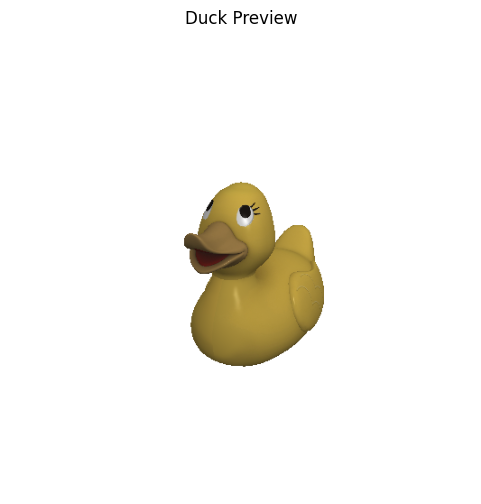

In [12]:
import matplotlib.pyplot as plt
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    PointLights
)


# Mesh preview
def render_mesh_preview(mesh, dist=2.5, elev=20, azim=30, image_size=512):
    R, T = look_at_view_transform(dist=dist, elev=elev, azim=azim)
    cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

    raster_settings = RasterizationSettings(
        image_size=image_size,
        blur_radius=0.0,
        faces_per_pixel=1
    )

    lights = PointLights(device=device, location=[[2.0, 2.0, 2.0]])

    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings),
        shader=SoftPhongShader(device=device, cameras=cameras, lights=lights)
    )

    image = renderer(mesh)[0, ..., :3].detach().cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Duck Preview")
    plt.show()

render_mesh_preview(mesh)

In [14]:
import os
from pytorch3d.renderer import (
    SoftSilhouetteShader,
    BlendParams
)


# Generation of multi-view RGB and silhouettes
def generate_multiview_dataset(
    mesh,
    num_views=40,
    image_size=128,
    dist=2.5,
    save_dir="duck_dataset"
):
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, "rgb"), exist_ok=True)
    os.makedirs(os.path.join(save_dir, "sil"), exist_ok=True)

    azims = torch.linspace(-180, 180, num_views)
    elevs = torch.linspace(-20, 40, num_views)

    R, T = look_at_view_transform(dist=dist, elev=elevs, azim=azims)
    cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

    rgb_raster = RasterizationSettings(
        image_size=image_size,
        blur_radius=0.0,
        faces_per_pixel=1
    )

    sil_raster = RasterizationSettings(
        image_size=image_size,
        blur_radius=np.log(1.0 / 1e-4 - 1.0) * 1e-4,
        faces_per_pixel=50
    )

    lights = PointLights(device=device, location=[[2.0, 2.0, 2.0]])

    rgb_renderer = MeshRenderer(
        rasterizer=MeshRasterizer(cameras=cameras, raster_settings=rgb_raster),
        shader=SoftPhongShader(device=device, cameras=cameras, lights=lights)
    )

    silhouette_renderer = MeshRenderer(
        rasterizer=MeshRasterizer(cameras=cameras, raster_settings=sil_raster),
        shader=SoftSilhouetteShader(
            blend_params=BlendParams(sigma=1e-4, gamma=1e-4)
        )
    )

    mesh_batch = mesh.extend(num_views)

    rgb_images = rgb_renderer(mesh_batch)[..., :3]
    sil_images = silhouette_renderer(mesh_batch)[..., 3]

    for i in range(num_views):
        rgb = (rgb_images[i].detach().cpu().numpy() * 255).astype(np.uint8)
        sil = (sil_images[i].detach().cpu().numpy() * 255).astype(np.uint8)

        Image.fromarray(rgb).save(os.path.join(save_dir, "rgb", f"view_{i:03d}.png"))
        Image.fromarray(sil).save(os.path.join(save_dir, "sil", f"view_{i:03d}.png"))

    return rgb_images.detach(), sil_images.detach(), cameras

target_rgbs, target_sils, train_cameras = generate_multiview_dataset(
    mesh,
    num_views=40,
    image_size=128,
    dist=2.5,
    save_dir="duck_dataset"
)

print("RGB shape:", target_rgbs.shape)
print("Silhouette shape:", target_sils.shape)

RGB shape: torch.Size([40, 128, 128, 3])
Silhouette shape: torch.Size([40, 128, 128])


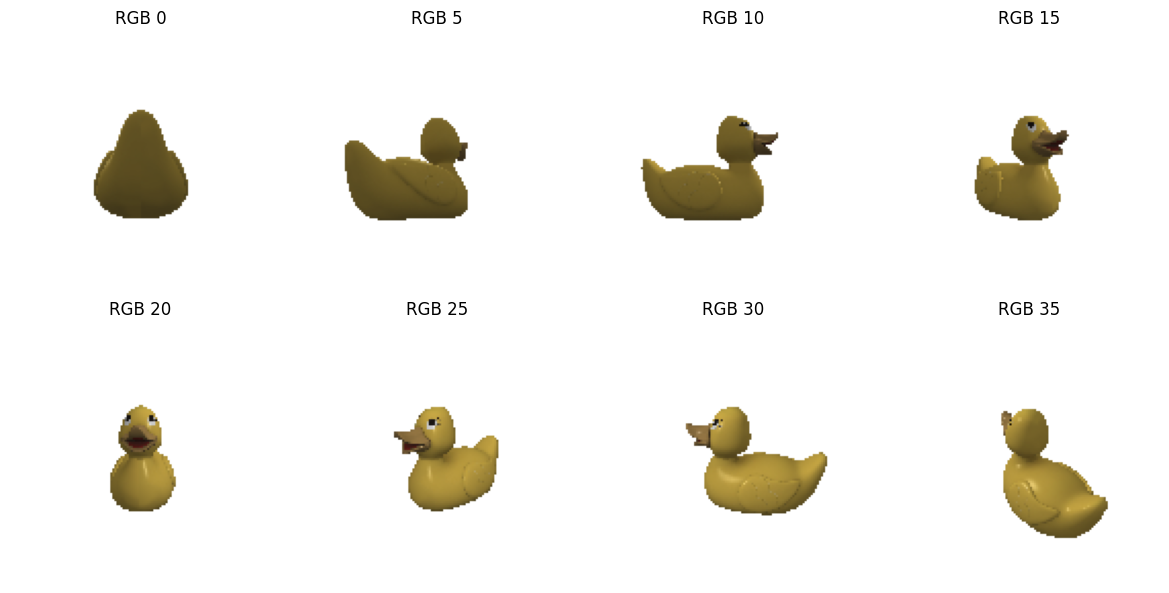

In [15]:
# Visualize some of the generated RGB images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
indices = [0, 5, 10, 15, 20, 25, 30, 35]

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(target_rgbs[idx].cpu().numpy())
    ax.set_title(f"RGB {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

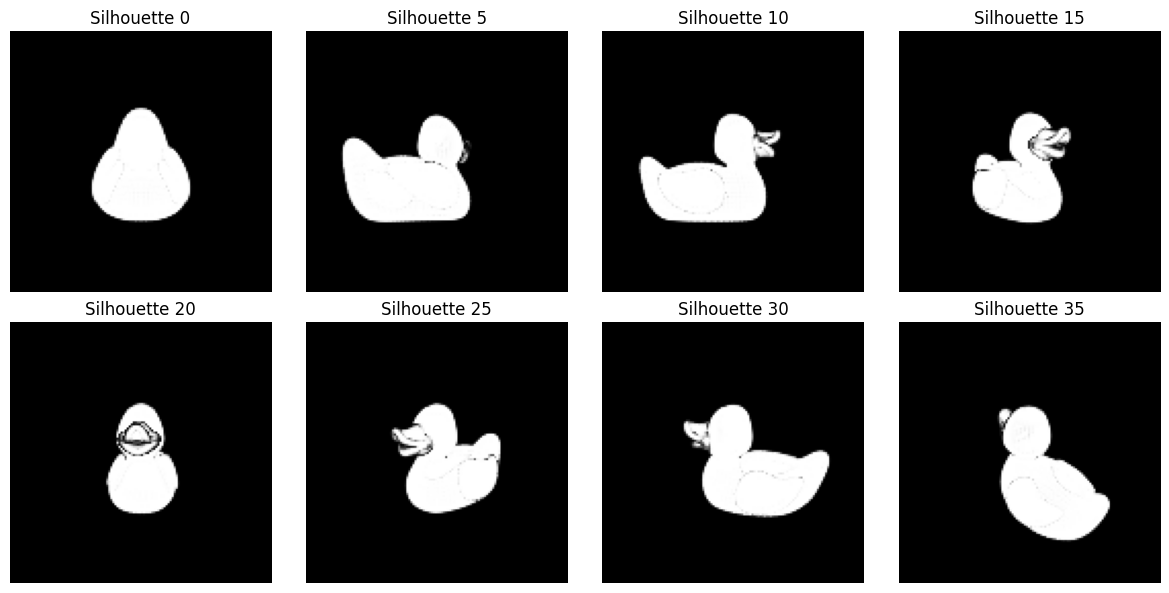

In [16]:
# Visualize some of the generated silhouette images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
indices = [0, 5, 10, 15, 20, 25, 30, 35]

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(target_sils[idx].cpu().numpy(), cmap="gray")
    ax.set_title(f"Silhouette {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
from pytorch3d.renderer import (
    NDCMultinomialRaysampler,
    EmissionAbsorptionRaymarcher,
    VolumeRenderer
)


# Volume Renderer
raysampler = NDCMultinomialRaysampler(
    image_width=128,
    image_height=128,
    n_pts_per_ray=64,
    min_depth=0.1,
    max_depth=3.0
)

raymarcher = EmissionAbsorptionRaymarcher()

volume_renderer = VolumeRenderer(
    raysampler=raysampler,
    raymarcher=raymarcher
).to(device)

print(volume_renderer)

VolumeRenderer(
  (renderer): ImplicitRenderer(
    (raysampler): NDCMultinomialRaysampler()
    (raymarcher): EmissionAbsorptionRaymarcher()
  )
)


In [18]:
import torch.nn as nn
import torch.nn.functional as F
from pytorch3d.structures import Volumes


# Volume Model
class VolumeModel(nn.Module):
    def __init__(self, grid_size=32):
        super().__init__()
        self.grid_size = grid_size

        self.log_densities = nn.Parameter(
            torch.randn(1, 1, grid_size, grid_size, grid_size) * 0.1
        )
        self.colors = nn.Parameter(
            torch.rand(1, 3, grid_size, grid_size, grid_size)
        )

    def make_volume(self, batch_size=1):
        densities = F.softplus(self.log_densities)
        features = torch.sigmoid(self.colors)

        if batch_size > 1:
            densities = densities.repeat(batch_size, 1, 1, 1, 1)
            features = features.repeat(batch_size, 1, 1, 1, 1)

        volume = Volumes(
            densities=densities,
            features=features,
            voxel_size=2.0 / self.grid_size
        )
        return volume

    def forward(self, batch_size=1):
        return self.make_volume(batch_size=batch_size)

model = VolumeModel(grid_size=32).to(device)
print(model)

VolumeModel()


In [19]:
# Volume Renderer
def render_volume_batch(model, cameras):
    batch_size = cameras.R.shape[0]
    volume = model(batch_size=batch_size)

    rendered = volume_renderer(cameras=cameras, volumes=volume)

    if isinstance(rendered, tuple):
        rendered = rendered[0]

    return rendered

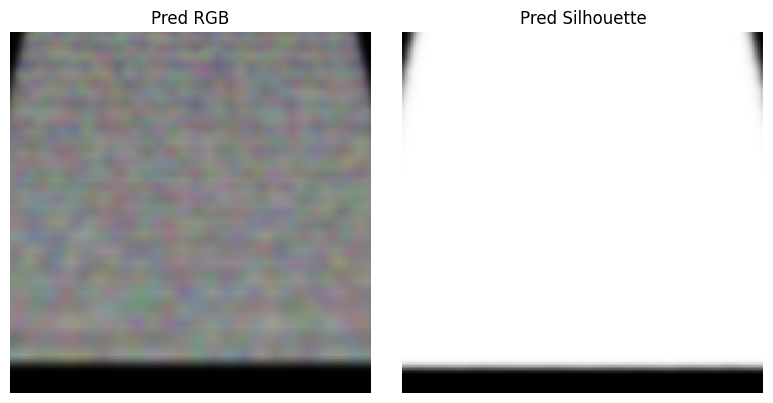

In [22]:
# Viewing the initial prediction
def show_volume_prediction(model, cameras, idx=0):
    with torch.no_grad():
        pred = render_volume_batch(model, cameras[idx])[0]

    rgb = pred[..., :3].detach().cpu().numpy()
    alpha = pred[..., 3].detach().cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(rgb)
    ax[0].set_title("Pred RGB")
    ax[0].axis("off")

    ax[1].imshow(alpha, cmap="gray")
    ax[1].set_title("Pred Silhouette")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

show_volume_prediction(model, train_cameras, 0)

In [25]:
# Train function
def train_volume_model(
    num_iters=300,
    lr=0.05,
    grid_size=32,
    snapshot_every=50,
    out_dir="train_run"
):
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(os.path.join(out_dir, "snapshots"), exist_ok=True)

    model = VolumeModel(grid_size=grid_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    snapshot_paths = []

    for it in range(1, num_iters + 1):
        optimizer.zero_grad()

        pred = render_volume_batch(model, train_cameras)

        pred_rgb = pred[..., :3]
        pred_sil = pred[..., 3]

        loss_sil = F.mse_loss(pred_sil, target_sils)
        loss_rgb = F.mse_loss(pred_rgb, target_rgbs)

        dens_reg = F.softplus(model.log_densities).mean()
        loss = 2.0 * loss_sil + 1.0 * loss_rgb + 0.01 * dens_reg

        loss.backward()
        optimizer.step()

        history.append(loss.item())

        if it % 25 == 0 or it == 1:
            print(
                f"iter {it:04d} | total={loss.item():.6f} | "
                f"sil={loss_sil.item():.6f} | rgb={loss_rgb.item():.6f}"
            )

        if it % snapshot_every == 0 or it == num_iters:
            with torch.no_grad():
                snap = render_volume_batch(model, train_cameras[[0]])[0, ..., :3]
                snap_img = (snap.detach().cpu().numpy() * 255).clip(0, 255).astype(np.uint8)

            snap_path = os.path.join(out_dir, "snapshots", f"snap_{it:04d}.png")
            Image.fromarray(snap_img).save(snap_path)
            snapshot_paths.append(snap_path)

    return model, history, snapshot_paths

In [26]:
# Training for 150 iterations
model_150, hist_150, snaps_150 = train_volume_model(
    num_iters=150,
    lr=0.05,
    grid_size=32,
    snapshot_every=50,
    out_dir="run_150"
)

iter 0001 | total=1.881712 | sil=0.769660 | rgb=0.335451
iter 0025 | total=1.642447 | sil=0.717451 | rgb=0.204422
iter 0050 | total=1.257082 | sil=0.498109 | rgb=0.259785
iter 0075 | total=0.727447 | sil=0.124622 | rgb=0.477828
iter 0100 | total=0.686749 | sil=0.064564 | rgb=0.557218
iter 0125 | total=0.678851 | sil=0.076116 | rgb=0.526234
iter 0150 | total=0.675411 | sil=0.082800 | rgb=0.509425


In [ ]:
# Training for 300 iterations
model_300, hist_300, snaps_300 = train_volume_model(
    num_iters=300,
    lr=0.05,
    grid_size=32,
    snapshot_every=50,
    out_dir="run_300"
)

In [28]:
# Training for 600 iterations
model_600, hist_600, snaps_600 = train_volume_model(
    num_iters=600,  
    lr=0.05,
    grid_size=32,
    snapshot_every=50,
    out_dir="run_600"
)

iter 0001 | total=1.882478 | sil=0.769795 | rgb=0.335948
iter 0025 | total=1.642965 | sil=0.717732 | rgb=0.204380
iter 0050 | total=1.255390 | sil=0.497111 | rgb=0.260085
iter 0075 | total=0.727543 | sil=0.124561 | rgb=0.478044
iter 0100 | total=0.686750 | sil=0.064600 | rgb=0.557145
iter 0125 | total=0.678867 | sil=0.076142 | rgb=0.526197
iter 0150 | total=0.675450 | sil=0.082782 | rgb=0.509498
iter 0175 | total=0.673285 | sil=0.081998 | rgb=0.508901
iter 0200 | total=0.671686 | sil=0.082128 | rgb=0.507042
iter 0225 | total=0.670443 | sil=0.082439 | rgb=0.505176
iter 0250 | total=0.669446 | sil=0.082584 | rgb=0.503888
iter 0275 | total=0.668630 | sil=0.082729 | rgb=0.502780
iter 0300 | total=0.667950 | sil=0.082844 | rgb=0.501870
iter 0325 | total=0.667376 | sil=0.082944 | rgb=0.501096
iter 0350 | total=0.666888 | sil=0.083024 | rgb=0.500449
iter 0375 | total=0.666468 | sil=0.083094 | rgb=0.499889
iter 0400 | total=0.666104 | sil=0.083152 | rgb=0.499408
iter 0425 | total=0.665787 | si

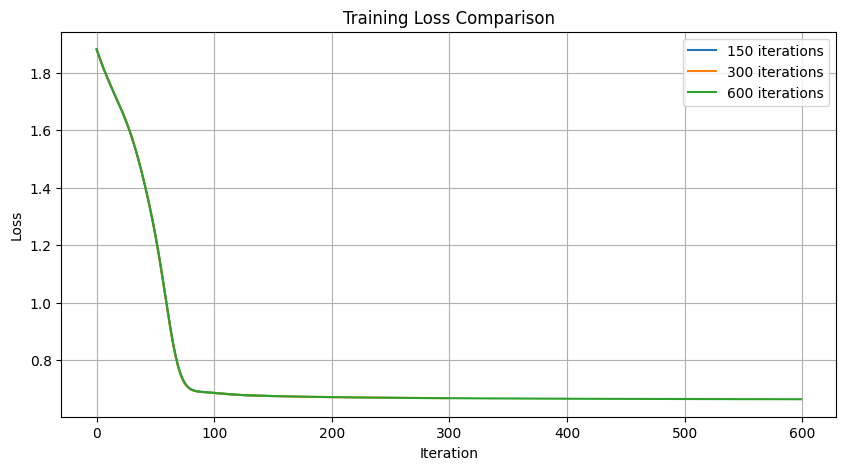

In [29]:
# Graph loss
plt.figure(figsize=(10, 5))
plt.plot(hist_150, label="150 iterations")
plt.plot(hist_300, label="300 iterations")
plt.plot(hist_600, label="600 iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
def make_gif_from_snapshots(snapshot_paths, gif_path, duration=600):
    frames = [Image.open(p) for p in snapshot_paths]

    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0
    )
    print("Saved:", gif_path)

make_gif_from_snapshots(snaps_150, "training_150.gif")
make_gif_from_snapshots(snaps_300, "training_300.gif")
make_gif_from_snapshots(snaps_600, "training_600.gif")

Saved: training_150.gif
Saved: training_300.gif
Saved: training_600.gif


In [32]:
def get_final_rgb(model, camera_idx=0):
    with torch.no_grad():
        pred = render_volume_batch(model, train_cameras[camera_idx])[0, ..., :3]
    return pred.detach().cpu().numpy()

img150 = get_final_rgb(model_150, 0)
img300 = get_final_rgb(model_300, 0)
img600 = get_final_rgb(model_600, 0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.016915092..0.9070152].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09064659..0.9300031].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10081714..0.9441924].


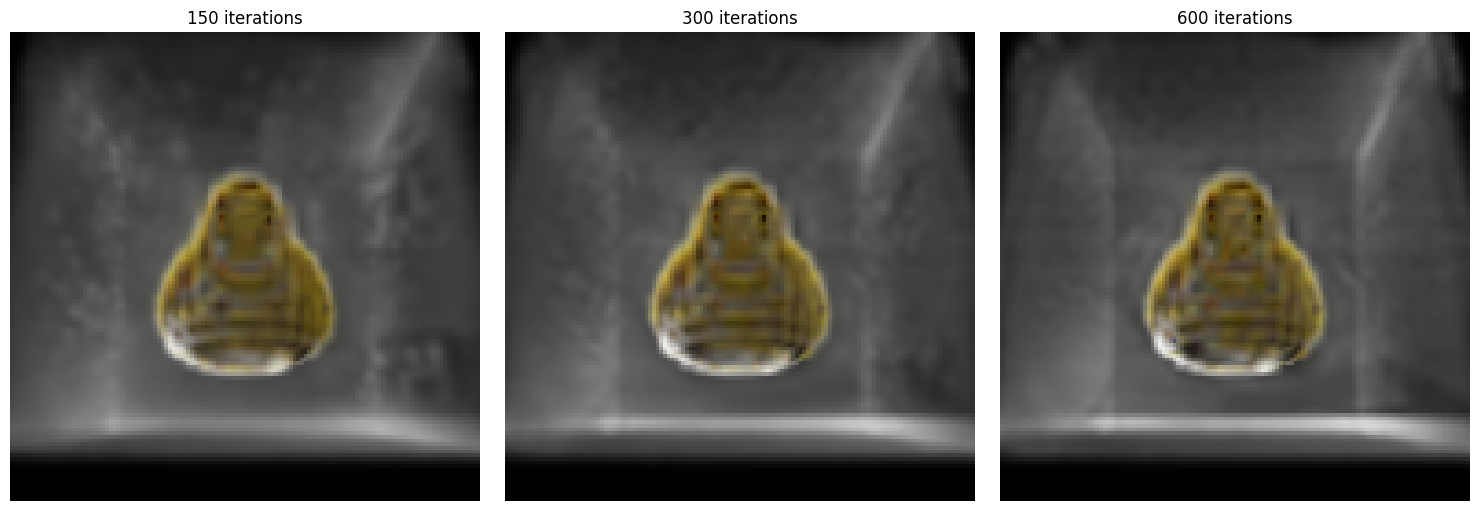

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img150)
ax[0].set_title("150 iterations")
ax[0].axis("off")

ax[1].imshow(img300)
ax[1].set_title("300 iterations")
ax[1].axis("off")

ax[2].imshow(img600)
ax[2].set_title("600 iterations")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [34]:
def get_final_alpha(model, camera_idx=0):
    with torch.no_grad():
        pred = render_volume_batch(model, train_cameras[camera_idx])[0, ..., 3]
    return pred.detach().cpu().numpy()

a150 = get_final_alpha(model_150, 0)
a300 = get_final_alpha(model_300, 0)
a600 = get_final_alpha(model_600, 0)
gt = target_sils[0].detach().cpu().numpy()

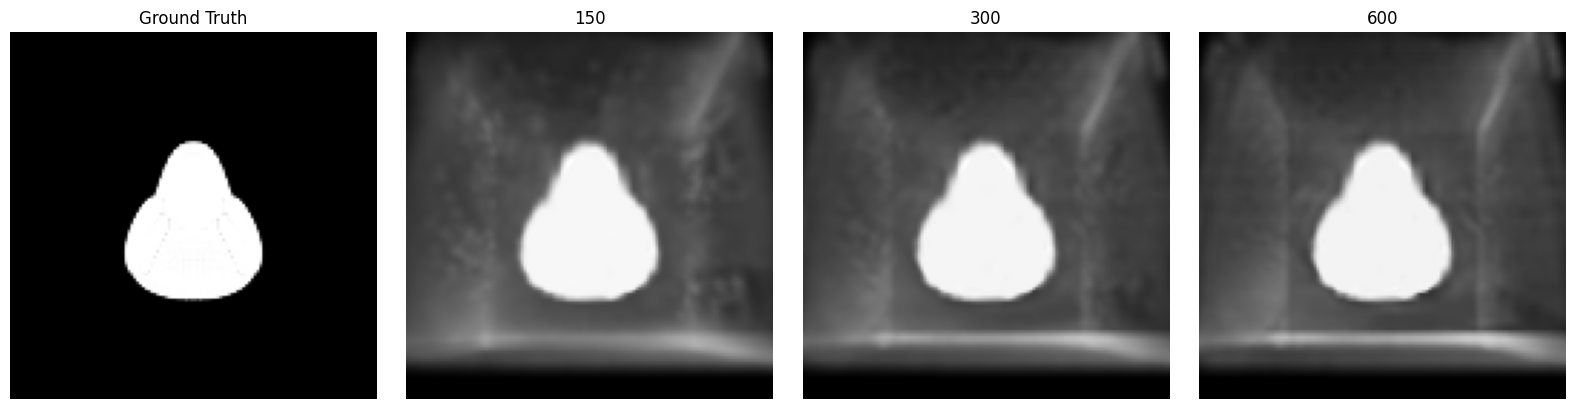

In [35]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(gt, cmap="gray")
ax[0].set_title("Ground Truth")
ax[0].axis("off")

ax[1].imshow(a150, cmap="gray")
ax[1].set_title("150")
ax[1].axis("off")

ax[2].imshow(a300, cmap="gray")
ax[2].set_title("300")
ax[2].axis("off")

ax[3].imshow(a600, cmap="gray")
ax[3].set_title("600")
ax[3].axis("off")

plt.tight_layout()
plt.show()

In [36]:
final_losses = {
    "150": hist_150[-1],
    "300": hist_300[-1],
    "600": hist_600[-1]
}

print(final_losses)

best_name = min(final_losses, key=final_losses.get)
best_model = {"150": model_150, "300": model_300, "600": model_600}[best_name]

print("Best model:", best_name)

{'150': 0.675410807132721, '300': 0.6679473519325256, '600': 0.6643795371055603}
Best model: 600


In [37]:
def render_rotating_volume(model, n_frames=60, dist=2.5, elev=20, out_gif="best_rotation.gif"):
    frames = []

    azims = torch.linspace(-180, 180, n_frames)
    elevs = torch.ones_like(azims) * elev

    R, T = look_at_view_transform(dist=dist, elev=elevs, azim=azims)
    cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

    with torch.no_grad():
        preds = render_volume_batch(model, cameras)[..., :3].detach().cpu().numpy()

    for i in range(n_frames):
        frame = (preds[i] * 255).clip(0, 255).astype(np.uint8)
        frames.append(Image.fromarray(frame))

    frames[0].save(
        out_gif,
        save_all=True,
        append_images=frames[1:],
        duration=100,
        loop=0
    )

    print("Saved:", out_gif)

render_rotating_volume(best_model, n_frames=60, out_gif="duck_best_rotation.gif")

Saved: duck_best_rotation.gif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04275447..0.9096702].


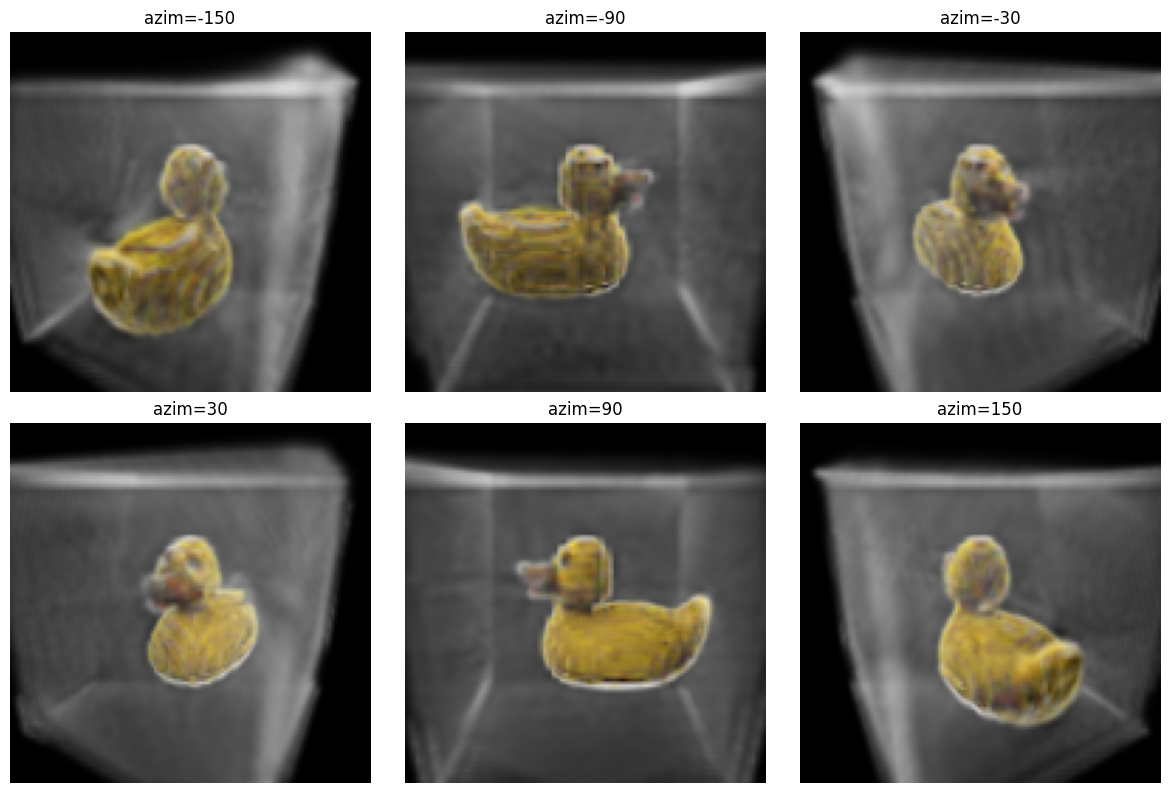

In [38]:
azim_list = [-150, -90, -30, 30, 90, 150]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, az in zip(axes.flatten(), azim_list):
    R, T = look_at_view_transform(dist=2.5, elev=20, azim=az)
    cam = FoVPerspectiveCameras(device=device, R=R, T=T)

    with torch.no_grad():
        img = render_volume_batch(best_model, cam)[0, ..., :3].detach().cpu().numpy()

    ax.imshow(img)
    ax.set_title(f"azim={az}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [39]:
os.makedirs("report_outputs", exist_ok=True)

Image.fromarray((img150 * 255).astype(np.uint8)).save("report_outputs/final_150.png")
Image.fromarray((img300 * 255).astype(np.uint8)).save("report_outputs/final_300.png")
Image.fromarray((img600 * 255).astype(np.uint8)).save("report_outputs/final_600.png")

Image.fromarray(
    (target_rgbs[0].cpu().numpy() * 255).astype(np.uint8)
).save("report_outputs/gt_view0.png")

print("Saved to report_outputs/")

Saved to report_outputs/
